# Toy Squares Paper Plots

This notebook loads `main_result_LTLDOG` and builds the paper-facing Toy Squares figures:

1. the compact Toy Squares layout with one base Diffusion Policy rollout per reached block,
2. a square metrics panel with success rate on top and environment steps below,
3. one shared-axis rollout example comparing LTLDoG and `hint_squared`,
4. a final strip arranging those three square panels next to each other.


In [7]:
from pathlib import Path
import csv
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.collections import LineCollection
from matplotlib.colors import to_rgba
from matplotlib.lines import Line2D
from matplotlib.offsetbox import AnnotationBbox, HPacker, TextArea
from matplotlib.transforms import Bbox

REPO_ROOT = Path('/home/moritz/src/guided-diffusion')
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from toy_squares.toy_squares_utils import _draw_blocks as draw_toy_blocks
from toy_squares.toy_squares_utils import _flip_y as flip_toy_y

RESULT_ROOT = REPO_ROOT / 'outputs/toy_squares_rollouts/baseline_ltldog/rollouts/paper_test/main_result_LTLDOG'
PLOT_DIR = RESULT_ROOT / 'paperplots'
PLOT_DIR.mkdir(parents=True, exist_ok=True)

LTLDOG_METHOD = 'ltldog_h128_compact_full_exec_tau0p001_scale0p10_g20'
EXTENDED_HORIZONS = [1, 2, 3, 4, 5]
DISPLAY_HORIZONS = EXTENDED_HORIZONS

# This is the LaTeX textwidth Moritz gave.  The final composite is saved at
# this exact width, so LaTeX should not need to shrink it further.
LATEX_TEXTWIDTH_PT = 397.48499
PT_PER_IN = 72.27
TEXTWIDTH_IN = LATEX_TEXTWIDTH_PT / PT_PER_IN
SQUARE_SIDE_IN = TEXTWIDTH_IN
FOUR_SQUARE_ROW_HEIGHT_IN = 0.43 * TEXTWIDTH_IN
# Manual row-layout knobs for the final four-panel figure.  The plotted
# square frames are equal-size and equal-spaced; metric y labels live in the
# inter-panel gaps instead of shrinking the metric panels.
FOUR_PANEL_AXIS_SIDE_IN = 1.08
FOUR_PANEL_OUTER_MARGIN_IN = 0.035
FOUR_PANEL_FRAME_GAP_IN = (
    TEXTWIDTH_IN - 2 * FOUR_PANEL_OUTER_MARGIN_IN - 4 * FOUR_PANEL_AXIS_SIDE_IN
) / 3
FOUR_PANEL_AXIS_BOTTOM_IN = 0.64
FOUR_PANEL_CROP_BOTTOM_IN = 0.055
FOUR_PANEL_CROP_TOP_IN = 1.88
FIG_DPI = 300

BLOCK_ORDER = ['blue', 'red', 'green', 'yellow']
BLOCK_COLORS = {
    'blue': '#4f79a7',
    'red': '#b85f5a',
    'green': '#5e9c73',
    'yellow': '#c8a84a',
}

OUR_BLUE = '#275fca'
OUR_BLUE_LIGHT = '#7c9ce6'
LTLDOG_GRAY = '#5f6368'
LTLDOG_GRAY_LIGHT = '#9aa0a6'
AXIS_GRAY = '#8a8a8a'
PANEL_FRAME_LW = 0.9
PANEL_TITLE_GAP_PT = 0.25
COMMON_ENV_XLIM = (-0.57, 0.57)
COMMON_ENV_YLIM = (-0.52, 0.62)
AGENT_RADIUS = 0.09


plt.rcParams.update({
    # Approximate LaTeX \texttt{} by preferring Computer Modern/CMU typewriter,
    # then falling back to the bundled DejaVu mono face.
    'font.family': 'monospace',
    'font.monospace': ['Computer Modern Typewriter', 'CMU Typewriter Text', 'DejaVu Sans Mono'],
    'mathtext.fontset': 'cm',
    'axes.labelsize': 6.5,
    'axes.titlesize': 7,
    'axes.titleweight': 'normal',
    'xtick.labelsize': 6,
    'ytick.labelsize': 6,
    'legend.fontsize': 5.5,
    'figure.dpi': FIG_DPI,
    'savefig.dpi': FIG_DPI,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
})


def load_json(path):
    with open(path, 'r', encoding='utf-8') as f:
        return json.load(f)


def save_fig(fig, stem, tight=True):
    save_kwargs = {'bbox_inches': 'tight', 'pad_inches': 0.02} if tight else {}
    fig.savefig(PLOT_DIR / f'{stem}.png', **save_kwargs)
    fig.savefig(PLOT_DIR / f'{stem}.pdf', **save_kwargs)


def save_fig_vertical_crop(fig, stem, bottom, top):
    # Preserve the exact textwidth and all internal panel geometry, but crop
    # unused vertical canvas.  Coordinates are in figure inches from bottom.
    fig_w, _ = fig.get_size_inches()
    crop = Bbox.from_extents(0.0, float(bottom), float(fig_w), float(top))
    fig.savefig(PLOT_DIR / f'{stem}.png', bbox_inches=crop, pad_inches=0.0)
    fig.savefig(PLOT_DIR / f'{stem}.pdf', bbox_inches=crop, pad_inches=0.0)


def latest_vector(value):
    arr = np.asarray(value, dtype=np.float32)
    if arr.ndim >= 2:
        arr = arr[-1]
    return arr.reshape(-1)


def load_trajectory(run_dir):
    with np.load(run_dir / 'low_level_obs.npz', allow_pickle=True) as data:
        agent_pos = np.asarray(data['agent_pos'])
    trajectory = np.stack([latest_vector(item) for item in agent_pos], axis=0)
    return flip_toy_y(trajectory)


def load_predicted_trajectory(run_dir):
    with np.load(run_dir / 'trace.npz', allow_pickle=True) as data:
        predicted = np.asarray(data.get('predicted', np.zeros((0, 12))), dtype=np.float32)
    if predicted.size == 0:
        return np.zeros((0, 2), dtype=np.float32)
    # LTLDoG stores full transition vectors [action(2), observation(10)].  The
    # first two observation entries are the imagined agent position.
    return flip_toy_y(predicted[:, 2:4])


def setup_blocks(setup_state):
    blocks = setup_state[2:10].reshape(4, 2) / 256.0 - 1.0
    agent = setup_state[:2] / 256.0 - 1.0
    angles = np.asarray(setup_state[10:14], dtype=float) if setup_state.shape[0] >= 14 else np.zeros(4)
    return flip_toy_y(blocks), flip_toy_y(agent), -angles


def square_zoom_limits(setup_state, trajectories=(), pad=0.14, min_half_width=0.48):
    blocks, agent, _ = setup_blocks(setup_state)
    point_sets = [blocks, agent[None]]
    for traj in trajectories:
        traj = np.asarray(traj)
        if traj.size:
            point_sets.append(traj[:, :2])
    pts = np.concatenate(point_sets, axis=0)
    lo = pts.min(axis=0)
    hi = pts.max(axis=0)
    center = 0.5 * (lo + hi)
    half = max(float(np.max(hi - lo)) * 0.5 + pad, min_half_width)
    return (center[0] - half, center[0] + half), (center[1] - half, center[1] + half)


def style_env_axis(ax, setup_state, trajectories=(), pad=0.14, min_half_width=0.48,
                   title=None, panel_label=None):
    blocks, agent, angles = setup_blocks(setup_state)
    colors = [BLOCK_COLORS[name] for name in BLOCK_ORDER]
    draw_toy_blocks(ax, blocks, angles, colors, radius=0.105, alpha=0.96, zorder=4)
    ax.scatter([agent[0]], [agent[1]], s=30, marker='o', c='#2f2f2f', alpha=0.95,
               edgecolors='white', linewidths=0.35, zorder=5)
    ax.set_xlim(*COMMON_ENV_XLIM)
    ax.set_ylim(*COMMON_ENV_YLIM)
    ax.set_aspect('equal')
    ax.axis('off')
    frame = plt.Rectangle((0, 0), 1, 1, transform=ax.transAxes, fill=False,
                          edgecolor='black', linewidth=PANEL_FRAME_LW,
                          clip_on=False, zorder=20)
    ax.add_patch(frame)
    if title:
        set_panel_title(ax, title, panel_label=panel_label)


def faded_path(ax, trajectory, color, linewidth=0.725, alpha=(0.18, 0.92), linestyle='solid', zorder=2):
    trajectory = np.asarray(trajectory, dtype=float)
    if len(trajectory) <= 1:
        return None
    segments = np.stack([trajectory[:-1], trajectory[1:]], axis=1)
    rgba = np.array(to_rgba(color))
    colors = np.tile(rgba, (len(segments), 1))
    colors[:, 3] = np.linspace(alpha[0], alpha[1], len(segments))
    line = LineCollection(segments, colors=colors, linewidths=linewidth, linestyles=linestyle,
                          capstyle='butt', joinstyle='round', zorder=zorder)
    ax.add_collection(line)
    return line


def style_metric_frame(ax):
    for spine in ax.spines.values():
        spine.set_color('black')
        spine.set_linewidth(PANEL_FRAME_LW)


def set_panel_title(ax, title, panel_label=None):
    # Matplotlib's monospace font gives Unicode thin/hair spaces normal-looking
    # width.  Pack the panel label and title as separate text boxes instead, so
    # the gap is a real point-size value and the square axes never get resized.
    textprops = {
        'fontsize': 7,
        'fontweight': 'normal',
        'fontfamily': 'monospace',
    }
    if panel_label:
        box = HPacker(
            children=[TextArea(panel_label, textprops=textprops), TextArea(title, textprops=textprops)],
            align='baseline', pad=0.0, sep=PANEL_TITLE_GAP_PT,
        )
    else:
        box = TextArea(title, textprops=textprops)
    artist = AnnotationBbox(
        box, (0.5, 1.0), xybox=(0.0, 3.0), xycoords='axes fraction',
        boxcoords='offset points', box_alignment=(0.5, 0.0), frameon=False, pad=0.0,
    )
    artist.set_clip_on(False)
    ax.add_artist(artist)
    return artist


def paper_legend_handles():
    marker_style = dict(marker='o', markersize=4.0, markerfacecolor='white', markeredgewidth=0.9)
    return [
        Line2D([0], [0], color=OUR_BLUE, lw=0.8, label='hint$^2$', **marker_style),
        Line2D([0], [0], color=LTLDOG_GRAY, lw=0.725, label='LTLDoG-S (Rollout)', **marker_style),
        Line2D([0], [0], color=LTLDOG_GRAY_LIGHT, lw=0.675, linestyle='--',
               label='LTLDoG-S (Planning)', **marker_style),
    ]


def horizon_dirs():
    return sorted([p for p in RESULT_ROOT.glob('horizon_*') if p.is_dir()])


def parse_horizon(path):
    return int(path.name.split('_')[1])


def method_summary(method, horizon):
    for hdir in horizon_dirs():
        if parse_horizon(hdir) == int(horizon):
            path = hdir / method / 'summary.json'
            if path.exists():
                summary = load_json(path)
                summary['_summary_path'] = str(path)
                summary['_method_dir'] = str(path.parent)
                return summary
    raise FileNotFoundError(f'No summary for method={method}, horizon={horizon}')


def all_method_summaries(method):
    rows = []
    for hdir in horizon_dirs():
        path = hdir / method / 'summary.json'
        if path.exists():
            summary = load_json(path)
            summary['_summary_path'] = str(path)
            summary['_method_dir'] = str(path.parent)
            rows.append(summary)
    return sorted(rows, key=lambda row: int(row['ltl_horizon']))


def record_run_dir(summary, record):
    run_dir = Path(record.get('run_dir', ''))
    if run_dir.exists():
        return run_dir
    return Path(summary['_method_dir']) / f"rollout_{int(record['rollout_idx']):03d}"


def load_diagnostic_success():
    csv_path = RESULT_ROOT / 'diagnostics_ltldog_imagined_vs_actual' / 'combined_success_summary.csv'
    if not csv_path.exists():
        return {}
    rows = {}
    with open(csv_path, 'r', encoding='utf-8') as f:
        for row in csv.DictReader(f):
            h = int(float(row['ltl_horizon']))
            rows[h] = {k: float(v) if v not in {'', None} else np.nan for k, v in row.items() if k != 'chain'}
            rows[h]['chain'] = row.get('chain', '')
    return rows


def collect_step_records():
    rows = []
    for method in ['ours', LTLDOG_METHOD]:
        for summary in all_method_summaries(method):
            for record in summary['records']:
                rows.append({
                    'method': 'ours' if method == 'ours' else 'ltldog',
                    'horizon': int(summary['ltl_horizon']),
                    'steps': int(record['steps']),
                    'complete': bool(record['complete']),
                    'chain': ' -> '.join(summary['chain']),
                })
    return rows


def mean_steps_by_horizon(method):
    values = {}
    summary_method = LTLDOG_METHOD if method == 'ltldog' else method
    for summary in all_method_summaries(summary_method):
        horizon = int(summary['ltl_horizon'])
        if horizon not in EXTENDED_HORIZONS:
            continue
        steps = [float(record['steps']) for record in summary['records']]
        values[horizon] = float(np.mean(steps)) if steps else np.nan
    return values


def draw_agent_touch(ax, pos, color='#2f2f2f'):
    touch = plt.Circle((pos[0], pos[1]), AGENT_RADIUS, facecolor=color, edgecolor='none',
                       alpha=0.12, zorder=10)
    ax.add_patch(touch)


def mark_first_hit(ax, pos, label, color, text=None, dx=0.012, dy=0.012):
    draw_agent_touch(ax, pos)
    ax.scatter([pos[0]], [pos[1]], s=17, facecolors='white', edgecolors=color,
               linewidths=0.8, zorder=12)
    if text:
        ax.text(pos[0] + dx, pos[1] + dy, text, color=color, fontsize=5.5,
                ha='left', va='bottom', zorder=13)


def mark_sequence_hits(ax, run_dir, color, text_offset=(0.012, 0.012), max_stage=None):
    summary = load_json(run_dir / 'rollout_summary.json')
    traj = load_trajectory(run_dir)
    for idx, reach in enumerate(summary.get('reaches', []), start=1):
        if max_stage is not None and idx > max_stage:
            continue
        t = min(int(reach['t']), len(traj) - 1)
        mark_first_hit(ax, traj[t], reach['label'], color, text=None, dx=text_offset[0], dy=text_offset[1])


## 1. Base Layout and Base Diffusion Policy Rollouts

One unguided/base Diffusion Policy rollout is shown for each block it reaches.  Each trajectory is truncated shortly after the first hit so the panel stays readable.


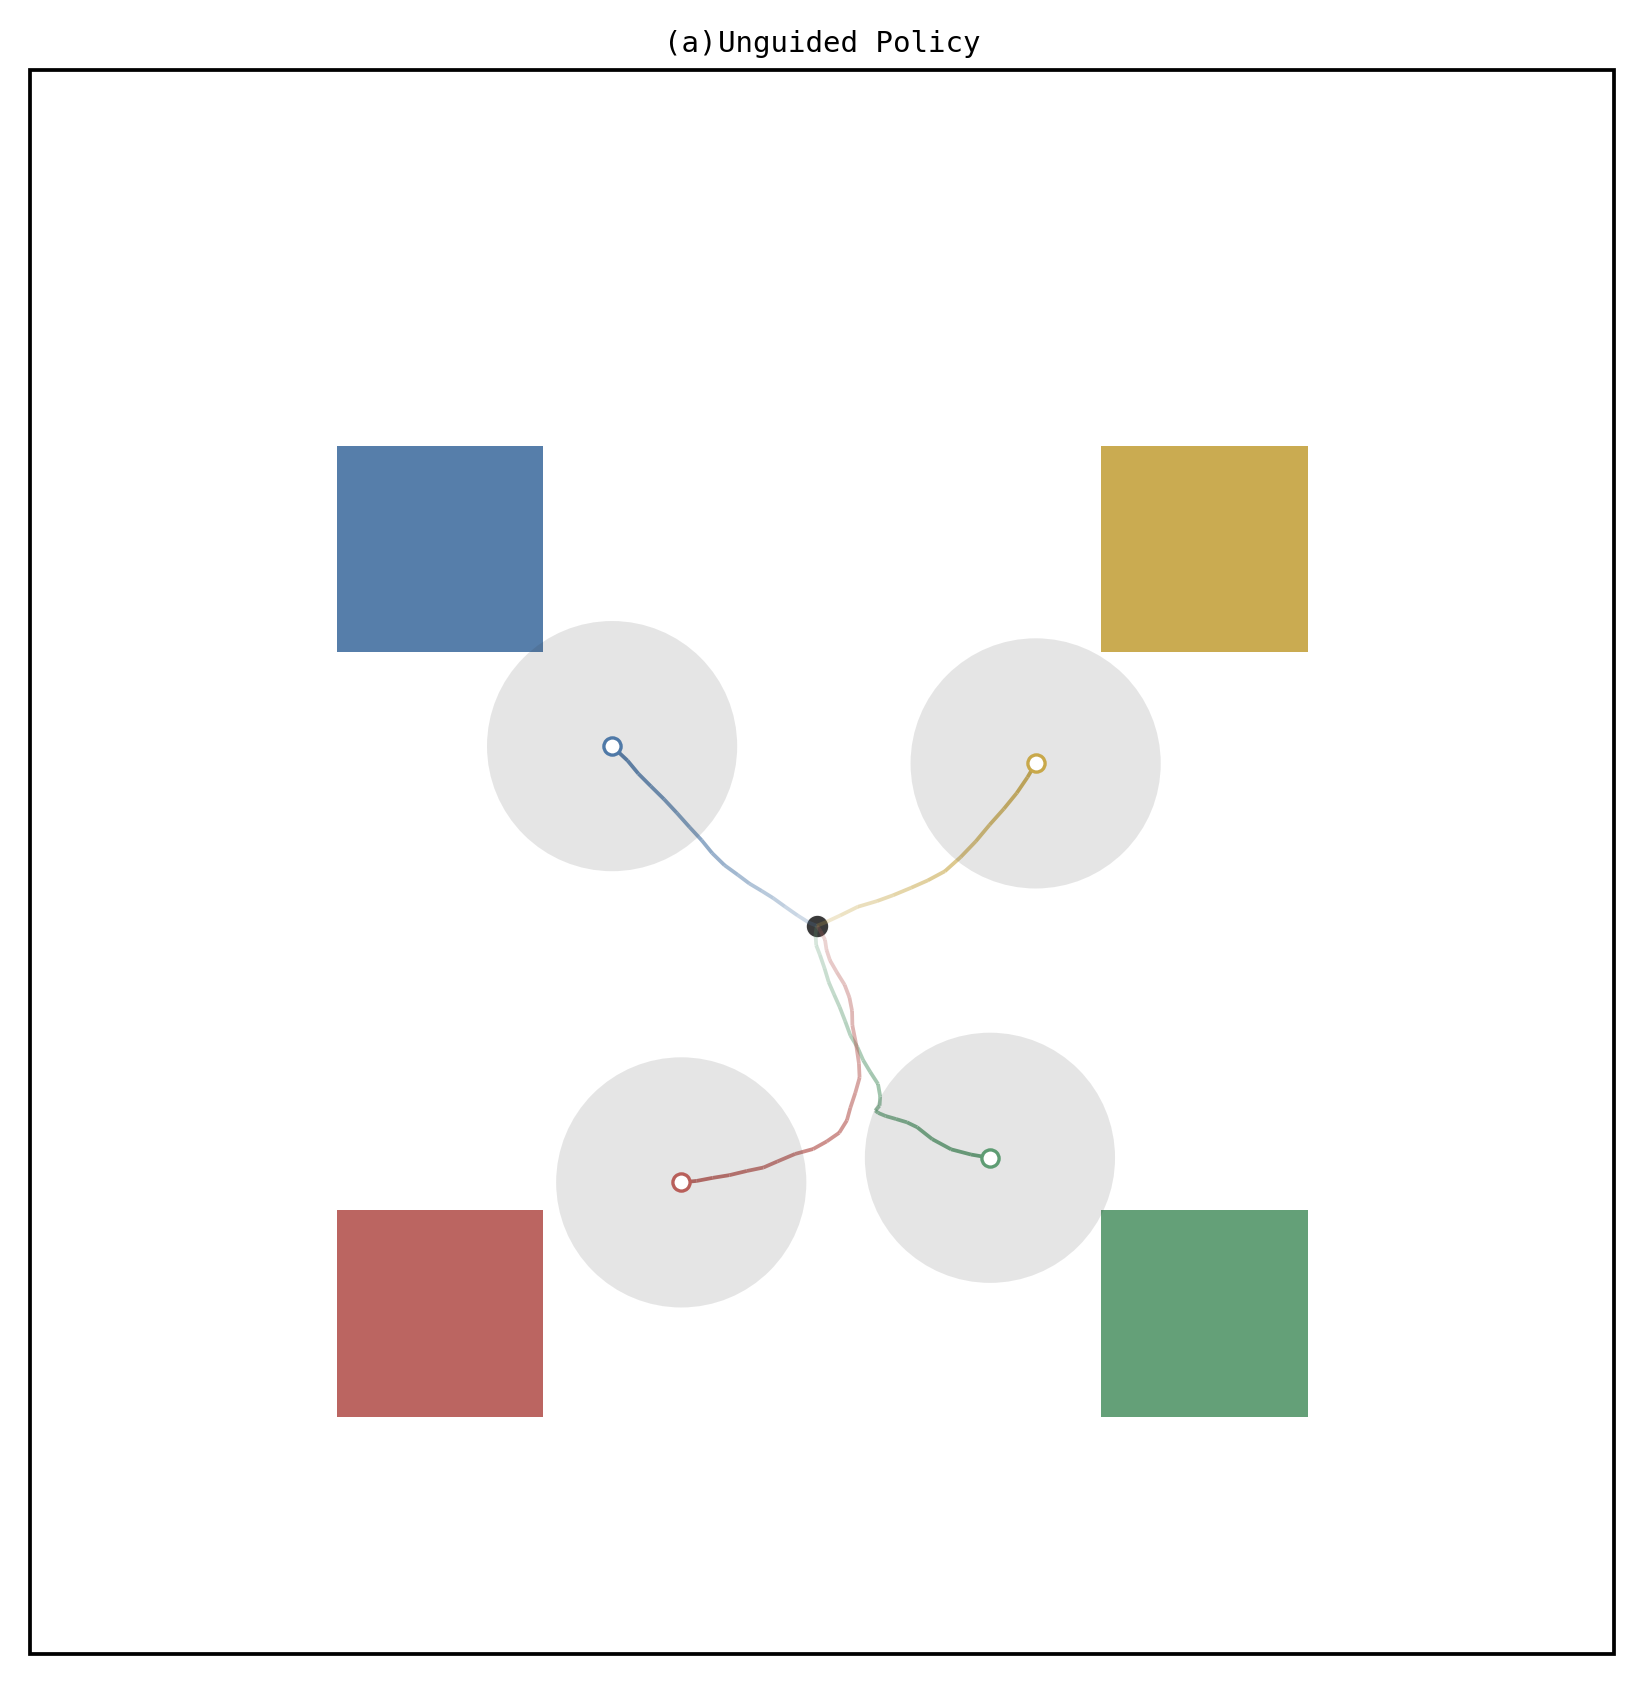

saved: /home/moritz/src/guided-diffusion/outputs/toy_squares_rollouts/baseline_ltldog/rollouts/paper_test/main_result_LTLDOG/paperplots/fig1_base_dp_layout_rollouts.png


In [8]:
BASE_ROLLOUT_BY_BLOCK = {
    'blue': 7,
    'yellow': 9,
    'green': 3,
    'red': 2,
}
BASE_AFTER_HIT_STEPS = 0


def base_rollout_trace(block):
    base_root = RESULT_ROOT / 'base_dp_rollouts'
    rollout_idx = BASE_ROLLOUT_BY_BLOCK[block]
    run_dir = base_root / f'rollout_{rollout_idx:03d}'
    summary = load_json(run_dir / 'rollout_summary.json')
    traj = load_trajectory(run_dir)
    hit_t = int(summary['first_hits'][block])
    end_t = min(len(traj) - 1, hit_t + BASE_AFTER_HIT_STEPS)
    return run_dir, summary, traj[:end_t + 1], hit_t


def plot_base_dp_panel(ax, legend=True):
    setup_state = np.load(RESULT_ROOT / 'base_dp_rollouts' / 'rollout_000' / 'setup_state.npy')
    traces = []
    for block in BASE_ROLLOUT_BY_BLOCK:
        _, _, traj, _ = base_rollout_trace(block)
        traces.append(traj)
    style_env_axis(ax, setup_state, trajectories=traces, pad=0.13, min_half_width=0.48,
                   title='Unguided Policy', panel_label='(a)')

    legend_handles = []
    for block, rollout_idx in BASE_ROLLOUT_BY_BLOCK.items():
        run_dir, summary, traj, hit_t = base_rollout_trace(block)
        faded_path(ax, traj, BLOCK_COLORS[block], linewidth=0.9, alpha=(0.22, 0.92), zorder=6)
        mark_first_hit(ax, traj[-1], block, BLOCK_COLORS[block], text=None)
        legend_handles.append(Line2D([0], [0], color=BLOCK_COLORS[block], lw=0.9, label=block))

    if legend:
        ax.legend(handles=legend_handles, loc='lower left', frameon=False, ncol=2,
                  handlelength=1.0, borderaxespad=0.2, columnspacing=0.7)


fig, ax = plt.subplots(figsize=(SQUARE_SIDE_IN, SQUARE_SIDE_IN), constrained_layout=True)
plot_base_dp_panel(ax, legend=False)
save_fig(fig, 'fig1_base_dp_layout_rollouts', tight=False)
plt.show()
print('saved:', PLOT_DIR / 'fig1_base_dp_layout_rollouts.png')


## 2/3. Metrics Square

The top axis shows satisfaction over the first three LTL prefix lengths.  The dashed blue continuation marks the intended `hint_squared` capacity beyond the budget-limited measured horizon, and the vertical dashed line separates measured H1-H3 from that continuation.  The lower axis shows environment steps without method-specific x-offsets.


'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


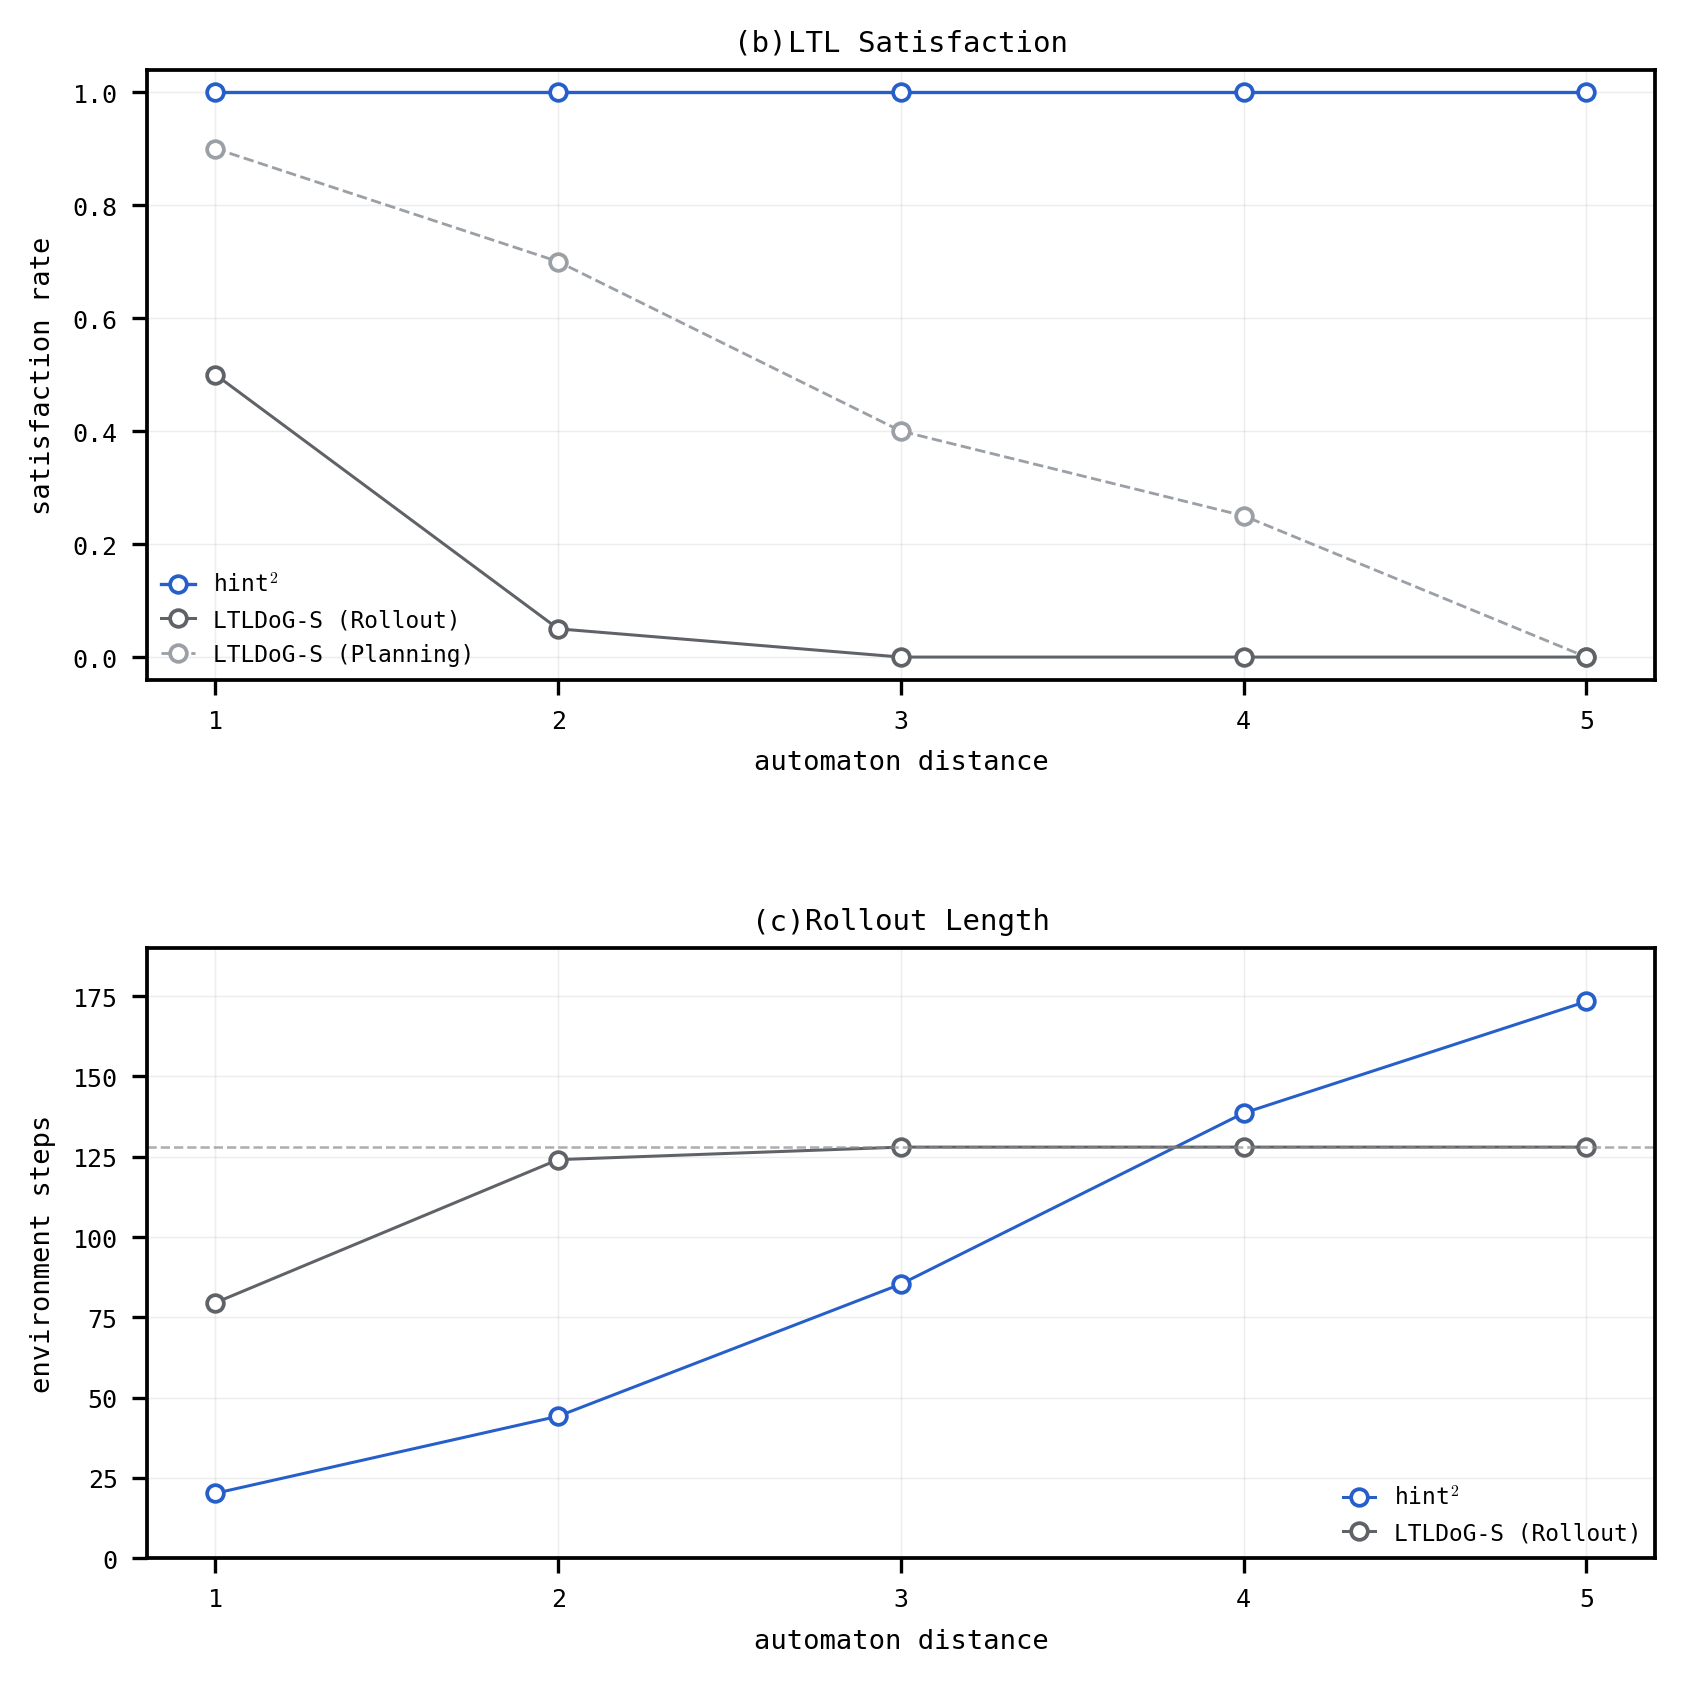

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


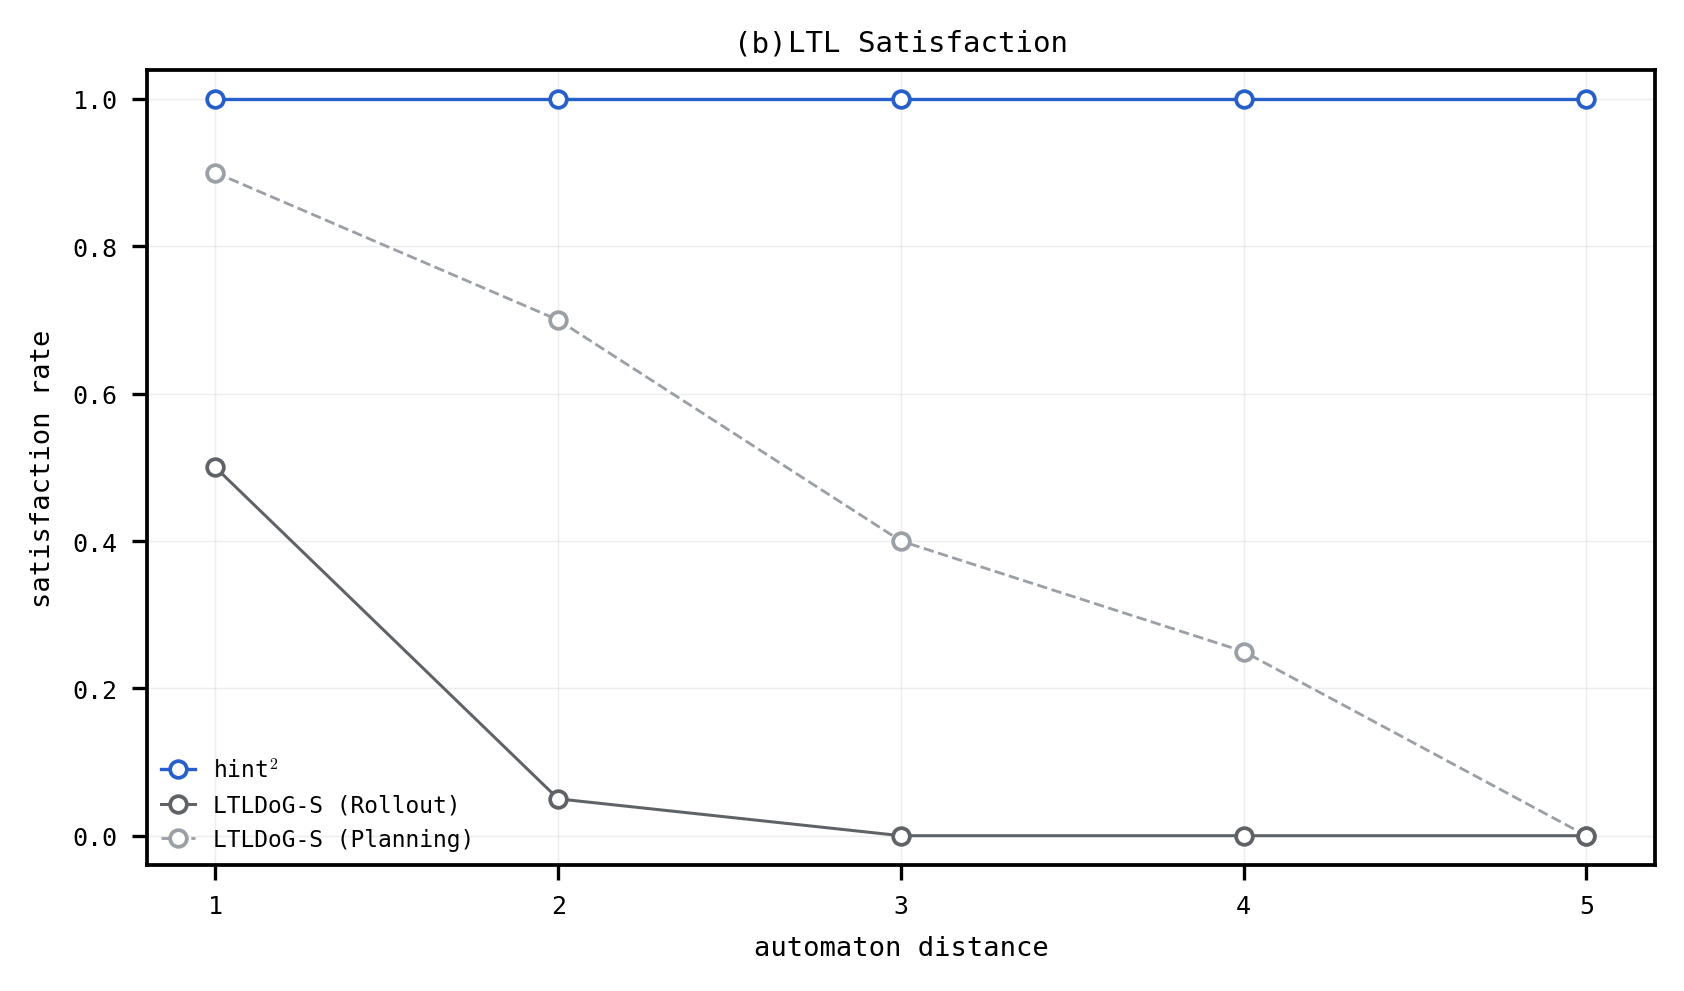

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


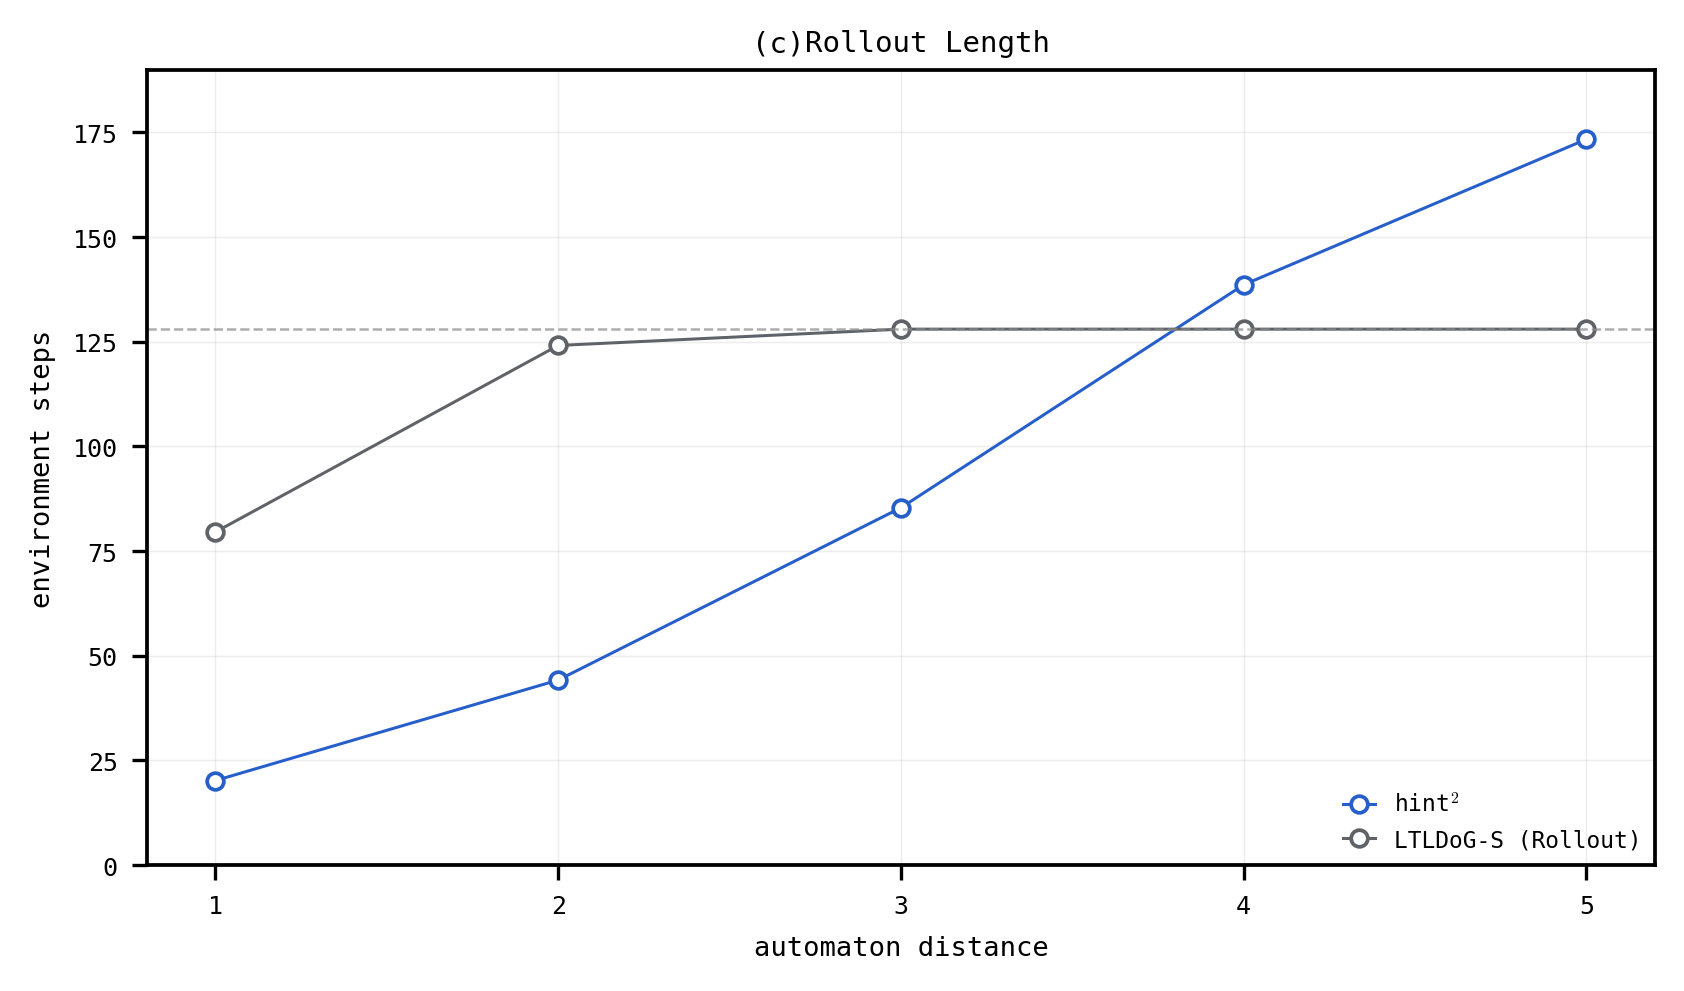

1 hint_squared 1.0 LTLDoG imagined 0.9 LTLDoG actual 0.5
2 hint_squared 1.0 LTLDoG imagined 0.7 LTLDoG actual 0.05
3 hint_squared 1.0 LTLDoG imagined 0.4 LTLDoG actual 0.0
4 hint_squared 1.0 LTLDoG imagined 0.25 LTLDoG actual 0.0
5 hint_squared 1.0 LTLDoG imagined 0.0 LTLDoG actual 0.0


In [9]:
def metric_values():
    diag = load_diagnostic_success()
    ours_summaries = all_method_summaries('ours')
    ltldog_summaries = all_method_summaries(LTLDOG_METHOD)
    ours_actual = {int(s['ltl_horizon']): float(s['success_rate']) for s in ours_summaries}
    ltldog_actual = {int(s['ltl_horizon']): float(s['success_rate']) for s in ltldog_summaries}
    ltldog_imagined = {
        h: diag.get(h, {}).get('ltldog_imagined_generated_blocks', np.nan)
        for h in EXTENDED_HORIZONS
    }
    return ours_actual, ltldog_actual, ltldog_imagined


def plot_success_axis(ax, legend=True, compact=False):
    ours_actual, ltldog_actual, ltldog_imagined = metric_values()
    h = EXTENDED_HORIZONS
    marker_kwargs_ours = dict(marker='o', markersize=4.0, markerfacecolor='white', markeredgewidth=0.9)
    marker_kwargs_imagined = dict(marker='o', markersize=4.0, markerfacecolor='white', markeredgewidth=0.9)
    marker_kwargs_actual = dict(marker='o', markersize=4.0, markerfacecolor='white', markeredgewidth=0.9)
    ax.plot(h, [ours_actual.get(x, np.nan) for x in h], linewidth=0.8, color=OUR_BLUE,
            label='hint$^2$', **marker_kwargs_ours)
    ax.plot(h, [ltldog_imagined.get(x, np.nan) for x in h], linewidth=0.675,
            linestyle='--', color=LTLDOG_GRAY_LIGHT, label='LTLDoG-S (Planning)', **marker_kwargs_imagined)
    ax.plot(h, [ltldog_actual.get(x, np.nan) for x in h], linewidth=0.725,
            color=LTLDOG_GRAY, label='LTLDoG-S (Rollout)', **marker_kwargs_actual)
    ax.set_xlim(0.8, 5.2)
    ax.set_ylim(-0.04, 1.04)
    ax.set_xticks([1, 2, 3, 4, 5])
    set_panel_title(ax, 'LTL Satisfaction', panel_label='(b)')
    ax.set_xlabel('automaton distance')
    ax.set_ylabel('satisfaction rate')
    if compact:
        ax.tick_params(axis='both', pad=1.0)
        ax.xaxis.labelpad = 1.0
        ax.yaxis.labelpad = 1.0
    ax.grid(True, alpha=0.22, linewidth=0.35)
    style_metric_frame(ax)
    if legend:
        ax.legend(handles=paper_legend_handles(), loc='lower left', frameon=False,
                  handlelength=1.5, borderaxespad=0.2)


def plot_steps_axis(ax, legend=True, compact=False):
    method_specs = {
        'ours': ('hint$^2$', OUR_BLUE, 0.725),
        'ltldog': ('LTLDoG-S (Rollout)', LTLDOG_GRAY, 0.725),
    }
    for method, (label, color, line_width) in method_specs.items():
        means = mean_steps_by_horizon(method)
        x = [h for h in EXTENDED_HORIZONS if h in means]
        y = [means[h] for h in x]
        marker_kwargs = dict(marker='o', markersize=4.0, markerfacecolor='white', markeredgewidth=0.9)
        ax.plot(x, y, linewidth=line_width, color=color, label=label, **marker_kwargs)
    ax.axhline(128, color=AXIS_GRAY, linestyle='--', linewidth=0.6, alpha=0.70)
    ax.set_xlim(0.8, 5.2)
    ax.set_ylim(0, 190)
    ax.set_xticks(EXTENDED_HORIZONS)
    set_panel_title(ax, 'Rollout Length', panel_label='(c)')
    ax.set_xlabel('automaton distance')
    ax.set_ylabel('env steps' if compact else 'environment steps')
    if compact:
        ax.tick_params(axis='both', pad=1.0)
        ax.xaxis.labelpad = 1.0
        ax.yaxis.labelpad = 1.0
    ax.grid(True, alpha=0.22, linewidth=0.35)
    style_metric_frame(ax)
    if legend:
        ax.legend(loc='lower right', frameon=False, handlelength=1.4, borderaxespad=0.2)


def plot_metrics_square(fig=None, subplotspec=None, legend=True, compact=False):
    if fig is None:
        fig = plt.figure(figsize=(SQUARE_SIDE_IN, SQUARE_SIDE_IN), constrained_layout=True)
        gs = fig.add_gridspec(2, 1, height_ratios=[1.0, 1.0], hspace=0.16)
    else:
        gs = subplotspec.subgridspec(2, 1, height_ratios=[1.0, 1.0], hspace=0.18)
    ax_success = fig.add_subplot(gs[0, 0])
    ax_steps = fig.add_subplot(gs[1, 0])
    plot_success_axis(ax_success, legend=legend, compact=compact)
    plot_steps_axis(ax_steps, legend=legend, compact=compact)
    return fig, (ax_success, ax_steps)


fig, axes = plot_metrics_square(legend=True)
save_fig(fig, 'fig2_3_metrics_square')
plt.show()

fig_success, ax_success = plt.subplots(figsize=(SQUARE_SIDE_IN, 0.58 * SQUARE_SIDE_IN), constrained_layout=True)
plot_success_axis(ax_success, legend=True)
save_fig(fig_success, 'fig2_success_rate_over_horizon')
plt.show()

fig_steps, ax_steps = plt.subplots(figsize=(SQUARE_SIDE_IN, 0.58 * SQUARE_SIDE_IN), constrained_layout=True)
plot_steps_axis(ax_steps, legend=True)
save_fig(fig_steps, 'fig3_steps_taken_over_horizon')
plt.show()

ours_actual, ltldog_actual, ltldog_imagined = metric_values()
for h in DISPLAY_HORIZONS:
    print(h, 'hint_squared', ours_actual.get(h), 'LTLDoG imagined', ltldog_imagined.get(h), 'LTLDoG actual', ltldog_actual.get(h))


## 4. Shared Rollout Example

The example overlays a successful full-execution LTLDoG `blue -> yellow` rollout with a successful four-step `hint_squared` rollout.  LTLDoG imagined motion is dashed gray; executed LTLDoG motion is solid gray; `hint_squared` is blue.


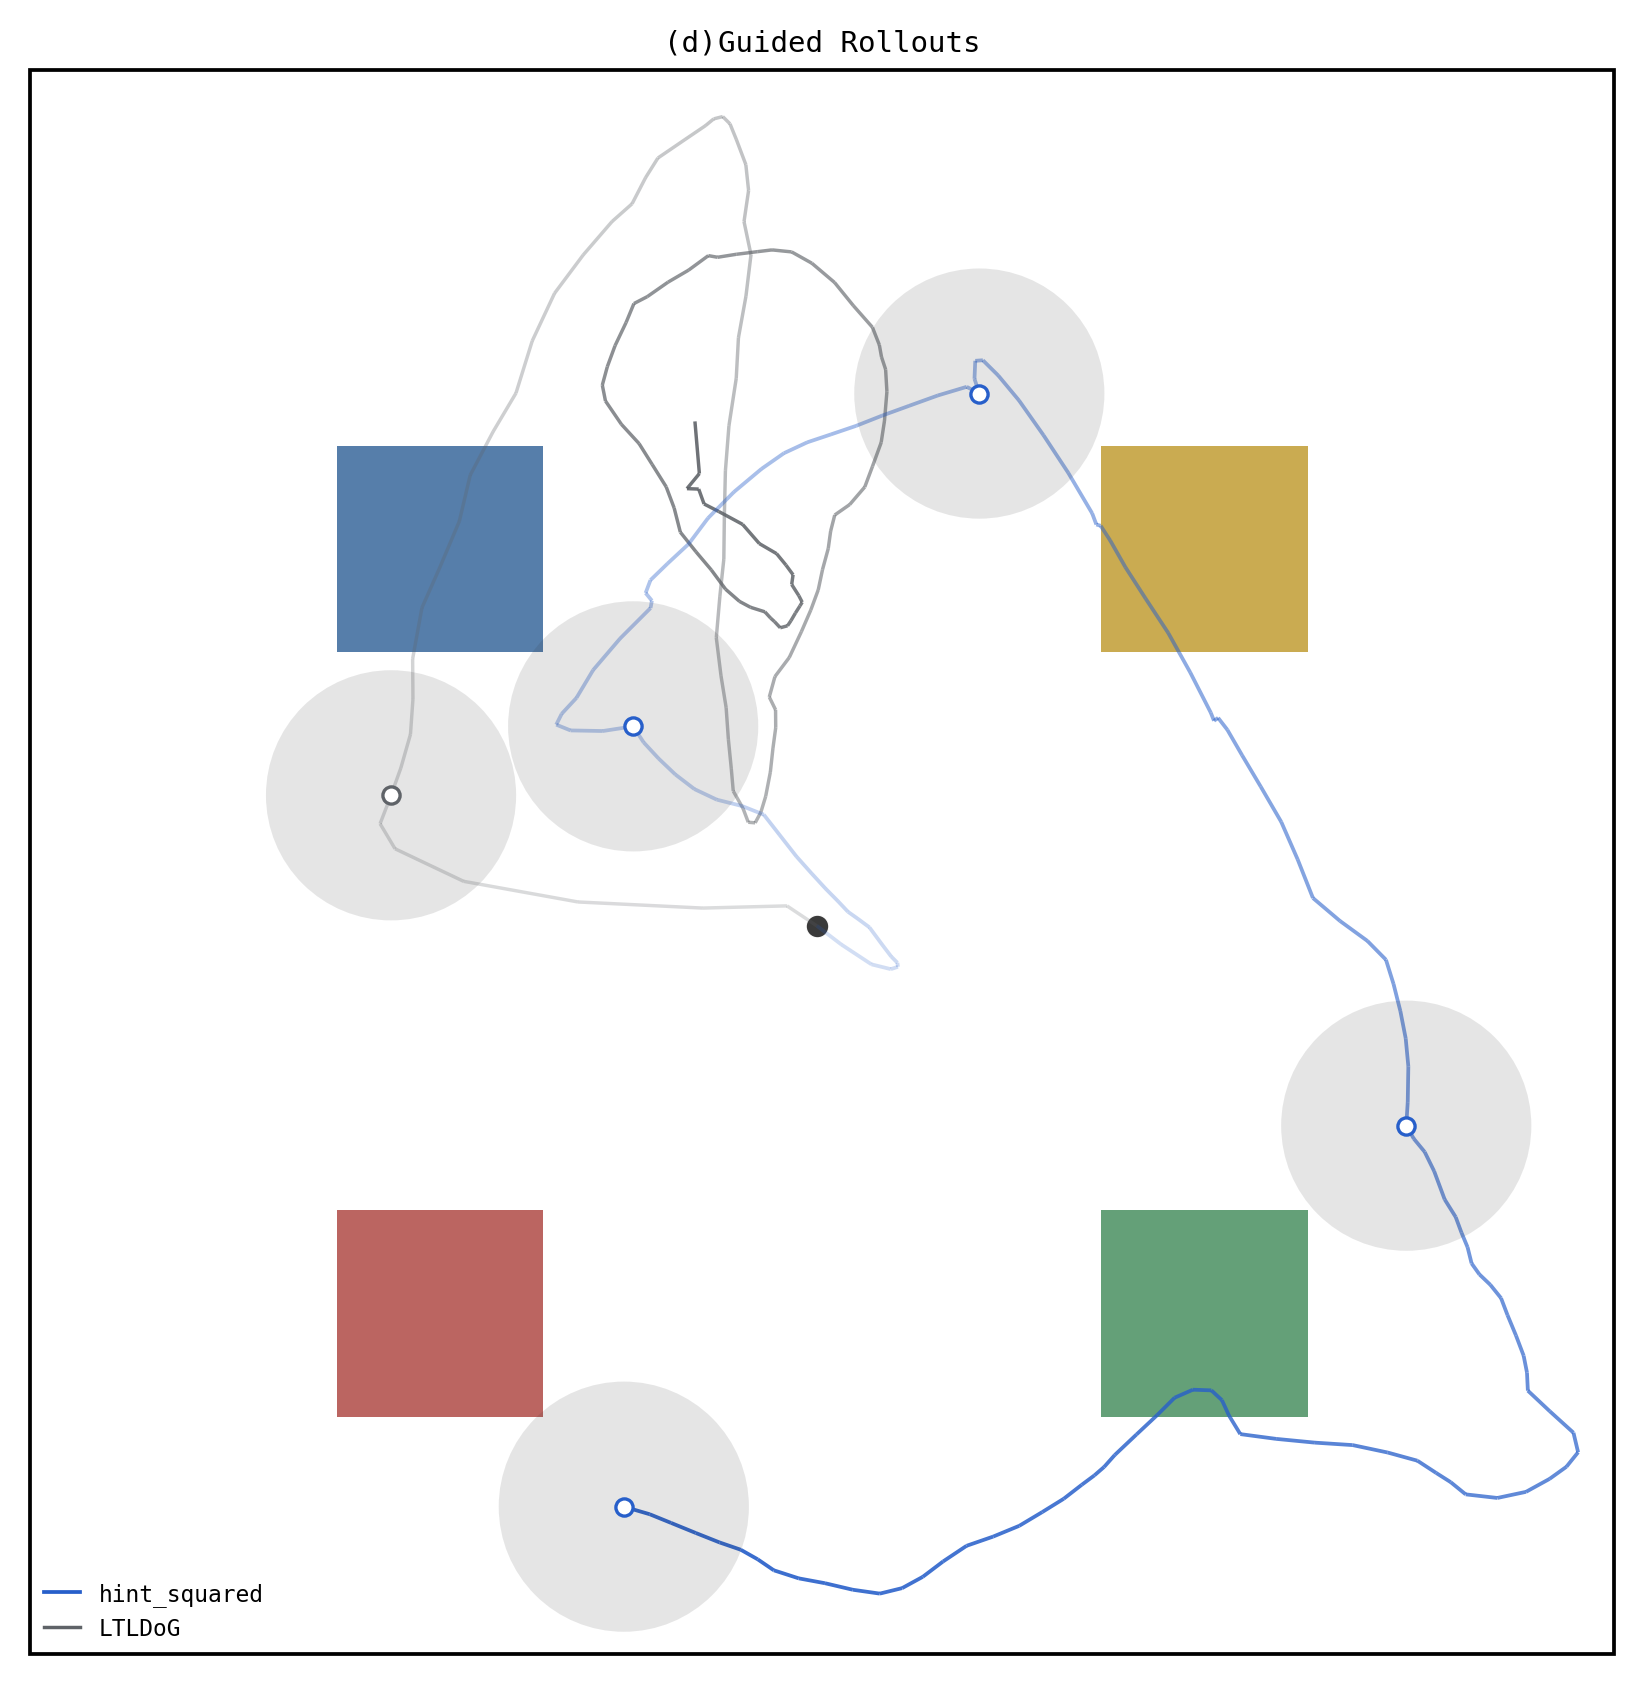

LTLDoG example: /home/moritz/src/guided-diffusion/outputs/toy_squares_rollouts/baseline_ltldog/rollouts/paper_test/main_result_LTLDOG/horizon_03_blue_yellow_green/ltldog_h128_compact_full_exec_tau0p001_scale0p10_g20/rollout_007
hint_squared example: /home/moritz/src/guided-diffusion/outputs/toy_squares_rollouts/baseline_ltldog/rollouts/paper_test/main_result_LTLDOG/horizon_04_blue_yellow_green_red/ours/rollout_000


In [10]:
def first_successful_run(method, horizon):
    summary = method_summary(method, horizon)
    record = next(record for record in summary['records'] if record['complete'])
    return summary, record_run_dir(summary, record)


LTLDOG_EXAMPLE_RUN = RESULT_ROOT / 'horizon_03_blue_yellow_green' / LTLDOG_METHOD / 'rollout_007'


def plot_example_overlay_panel(ax, legend=True):
    ltldog_run = LTLDOG_EXAMPLE_RUN
    ours_h4, ours_run = first_successful_run('ours', 4)

    ltldog_actual = load_trajectory(ltldog_run)
    ours_actual = load_trajectory(ours_run)
    setup_state = np.load(ltldog_run / 'setup_state.npy')

    trajectories_for_zoom = [ltldog_actual, ours_actual]
    style_env_axis(ax, setup_state, trajectories=trajectories_for_zoom, pad=0.13, min_half_width=0.50,
                   title='Guided Rollouts', panel_label='(d)')

    faded_path(ax, ltldog_actual, LTLDOG_GRAY, linewidth=0.825, alpha=(0.22, 0.90), zorder=7)
    faded_path(ax, ours_actual, OUR_BLUE, linewidth=0.9, alpha=(0.20, 0.94), zorder=8)
    mark_sequence_hits(ax, ltldog_run, LTLDOG_GRAY, text_offset=(-0.030, 0.014))
    mark_sequence_hits(ax, ours_run, OUR_BLUE, text_offset=(0.014, -0.030))

    if legend:
        handles = [
            Line2D([0], [0], color=OUR_BLUE, lw=0.9, label='hint_squared'),
            Line2D([0], [0], color=LTLDOG_GRAY, lw=0.825, label='LTLDoG'),
        ]
        ax.legend(handles=handles, loc='lower left', frameon=False, handlelength=1.6, borderaxespad=0.2)
    return ltldog_run, ours_run


fig, ax = plt.subplots(figsize=(SQUARE_SIDE_IN, SQUARE_SIDE_IN), constrained_layout=True)
ltldog_run, ours_run = plot_example_overlay_panel(ax, legend=True)
save_fig(fig, 'fig4_example_overlay_rollouts', tight=False)
save_fig(fig, 'fig4_example_success_rollouts', tight=False)
plt.show()
print('LTLDoG example:', ltldog_run)
print('hint_squared example:', ours_run)


## Four-Square Row

This cell lays out the four paper panels as equally tall square axes in one row: base layout, satisfaction, rollout length, and guidance rollouts.


In [23]:

# Keep this as an explicit override cell for easy notebook tweaking.
COMMON_ENV_XLIM = (-0.57, 0.57)
COMMON_ENV_YLIM = (-0.52, 0.62)
AGENT_RADIUS = 0.09
PANEL_TITLE_GAP_PT = 0.5

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


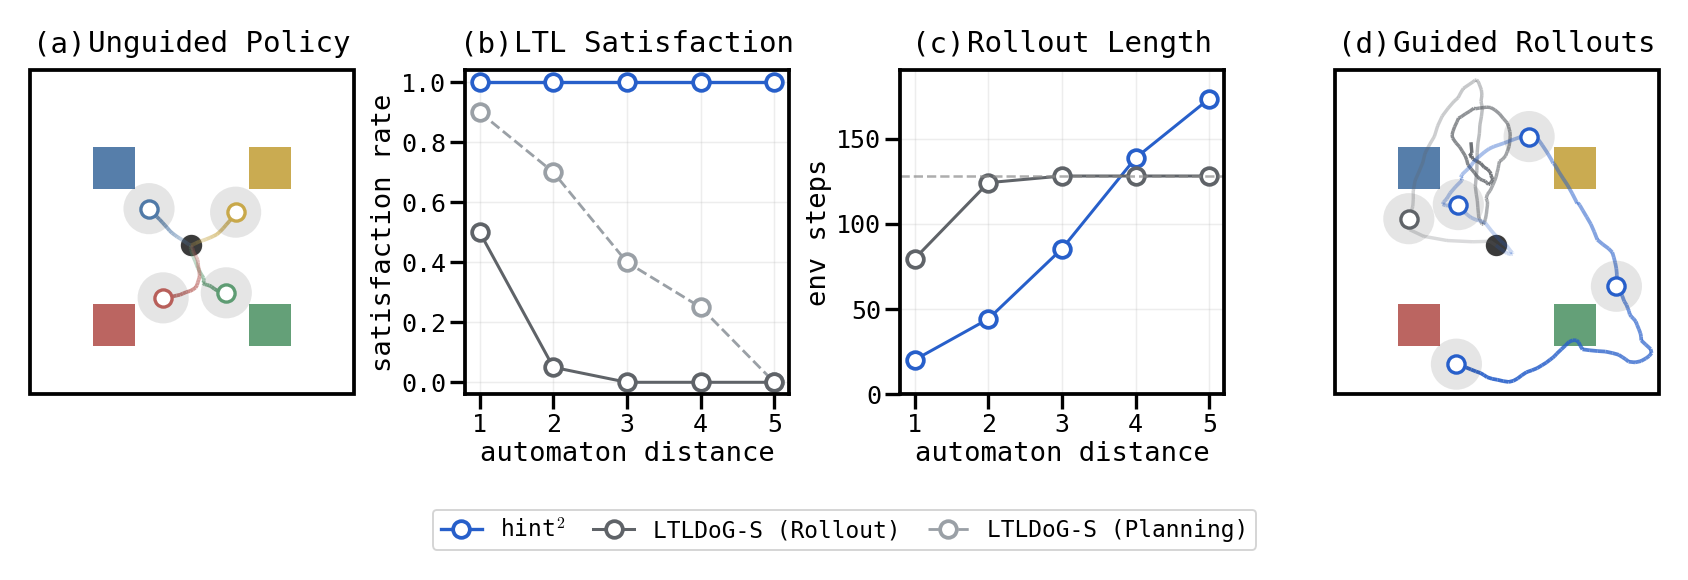

saved: /home/moritz/src/guided-diffusion/outputs/toy_squares_rollouts/baseline_ltldog/rollouts/paper_test/main_result_LTLDOG/paperplots/fig5_three_square_strip.png


In [24]:
def add_axes_in_inches(fig, left, bottom, width, height):
    fig_w, fig_h = fig.get_size_inches()
    return fig.add_axes([left / fig_w, bottom / fig_h, width / fig_w, height / fig_h])


def add_equal_square_row(fig):
    side = FOUR_PANEL_AXIS_SIDE_IN
    gap = FOUR_PANEL_FRAME_GAP_IN
    total_width = 4 * side + 3 * gap
    left = FOUR_PANEL_OUTER_MARGIN_IN + 0.5 * (TEXTWIDTH_IN - 2 * FOUR_PANEL_OUTER_MARGIN_IN - total_width)
    bottom = FOUR_PANEL_AXIS_BOTTOM_IN

    base_left = left
    success_left = base_left + side + gap
    steps_left = success_left + side + gap
    example_left = steps_left + side + gap

    return (
        add_axes_in_inches(fig, base_left, bottom, side, side),
        add_axes_in_inches(fig, success_left, bottom, side, side),
        add_axes_in_inches(fig, steps_left, bottom, side, side),
        add_axes_in_inches(fig, example_left, bottom, side, side),
    )


fig = plt.figure(figsize=(TEXTWIDTH_IN, FOUR_SQUARE_ROW_HEIGHT_IN), constrained_layout=False)
ax_base, ax_success, ax_steps, ax_example = add_equal_square_row(fig)

plot_base_dp_panel(ax_base, legend=False)
plot_success_axis(ax_success, legend=False, compact=True)
plot_steps_axis(ax_steps, legend=False, compact=True)
plot_example_overlay_panel(ax_example, legend=False)
legend = fig.legend(handles=paper_legend_handles(), loc='lower center', bbox_to_anchor=(0.5, 0.035),
                    ncol=3, frameon=True, fancybox=True, framealpha=1.0,
                    edgecolor='#d4d4d4', facecolor='white', handlelength=1.8,
                    columnspacing=1.2, borderpad=0.35)
legend.get_frame().set_linewidth(0.45)

save_fig_vertical_crop(fig, 'fig5_four_panel_square', FOUR_PANEL_CROP_BOTTOM_IN, FOUR_PANEL_CROP_TOP_IN)
save_fig_vertical_crop(fig, 'fig5_four_square_row', FOUR_PANEL_CROP_BOTTOM_IN, FOUR_PANEL_CROP_TOP_IN)
save_fig_vertical_crop(fig, 'fig5_three_square_strip', FOUR_PANEL_CROP_BOTTOM_IN, FOUR_PANEL_CROP_TOP_IN)
plt.show()
print('saved:', PLOT_DIR / 'fig5_three_square_strip.png')
